In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 1.Merge Data step

In [3]:
cpi = pd.read_csv("../data/raw/cpi_canada.csv")

unemployment = pd.read_csv("../data/raw/unemployment_canada.csv")

In [4]:
cpi.head()

,observation_date,CPALCY01CAM661N
0,1961-01-01,13.428804
1,1961-02-01,13.428804
2,1961-03-01,13.377873
3,1961-04-01,13.343919
4,1961-05-01,13.259034


In [5]:
unemployment.head()

,observation_date,LRUNTTTTCAM156S
0,1955-01-01,4.8
1,1955-02-01,4.7
2,1955-03-01,4.9
3,1955-04-01,4.5
4,1955-05-01,4.5


In [6]:
cpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  755 non-null    str    
 1   CPALCY01CAM661N   755 non-null    float64
dtypes: float64(1), str(1)
memory usage: 11.9 KB


In [7]:
unemployment.info()

<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  858 non-null    str    
 1   LRUNTTTTCAM156S   858 non-null    float64
dtypes: float64(1), str(1)
memory usage: 13.5 KB


In [8]:
cpi = cpi.rename(columns={
    "observation_date": "Date",
    "CPALCY01CAM661N": "CPI"
})

unemployment = unemployment.rename(columns={
    "observation_date": "Date",
    "LRUNTTTTCAM156S": "Unemployment"
})

In [10]:
cpi["Date"] = pd.to_datetime(cpi["Date"])

unemployment["Date"] = pd.to_datetime(unemployment["Date"])

In [32]:
df = pd.merge(
    cpi,
    unemployment,
    on="Date"
)

df.head()

,Date,CPI,Unemployment
0,1961-01-01,13.428804,7.6
1,1961-02-01,13.428804,7.7
2,1961-03-01,13.377873,7.6
3,1961-04-01,13.343919,7.6
4,1961-05-01,13.259034,7.6


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          755 non-null    datetime64[us]
 1   CPI           755 non-null    float64       
 2   Unemployment  755 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 17.8 KB


### Merge dataset

I select another key factor `unemployment` and I use the `Date` as common column merge it with `CPI`.Merging allows us to analyze relationships between multiple economic indicators rather than studying each dataset separately.


## 2. Correlation Between Inflation & Unemployment

In [13]:
df["Inflation"] = df["CPI"].pct_change() * 100

df.head()

,Date,CPI,Unemployment,Inflation
0,1961-01-01,13.428804,7.6,NaN
1,1961-02-01,13.428804,7.7,0.000000
2,1961-03-01,13.377873,7.6,-0.379267
3,1961-04-01,13.343919,7.6,-0.253807
4,1961-05-01,13.259034,7.6,-0.636132


In [14]:
df = df.dropna()

In [16]:
df[["Inflation", "Unemployment"]].corr()


,Inflation,Unemployment
Inflation,1.000000,-0.015461
Unemployment,-0.015461,1.000000


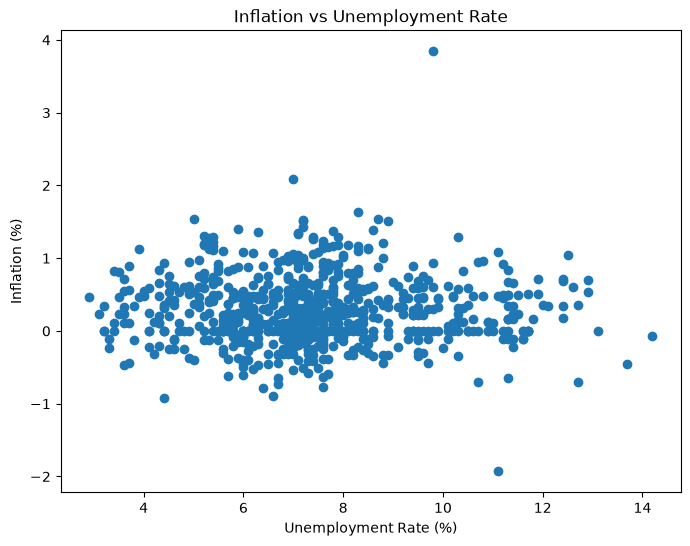

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Unemployment"],
    df["Inflation"]
)

plt.title("Inflation vs Unemployment Rate")

plt.xlabel("Unemployment Rate (%)")

plt.ylabel("Inflation (%)")

plt.savefig("../images/inflation_vs_unemployment.png", dpi=300)

plt.show()

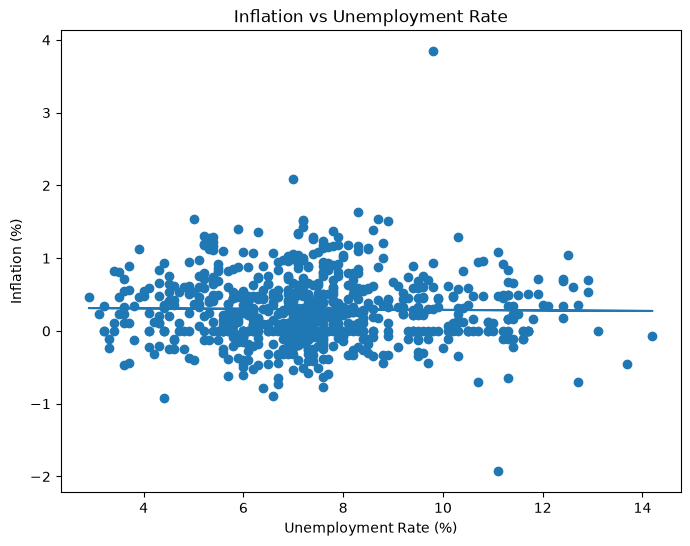

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(df["Unemployment"], df["Inflation"])

m, b = np.polyfit(df["Unemployment"], df["Inflation"], 1)

plt.plot(
    df["Unemployment"],
    m * df["Unemployment"] + b
)

plt.title("Inflation vs Unemployment Rate")

plt.xlabel("Unemployment Rate (%)")

plt.ylabel("Inflation (%)")

plt.savefig("../images/inflation_vs_unemployment_regression.png", dpi=300)

plt.show()


### Observations

- The scatter plot suggests a weak negative relationship between unemployment and Inflation.
- The regression line slopes slightly downward, indicating that higher unemployment is generally associated with lower CPI values in this dataset.


## 3. Predicting Inflation


In [20]:
X = df[["Unemployment"]]

y = df["Inflation"]

In [21]:
X.head()


,Unemployment
1,7.7
2,7.6
3,7.6
4,7.6
5,7.4


In [22]:
y.head()

1    0.000000
2   -0.379267
3   -0.253807
4   -0.636132
5    0.384123
Name: Inflation, dtype: float64

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(603, 1)
(151, 1)
(603,)
(151,)


### Preparing data

The unemployment rate is used as the input feature (X), while inflation is the target variable (y).

The dataset was split into training (80%) and testing (20%) subsets. This ensures that the model is evaluated on unseen data, providing a more reliable assessment of its predictive performance.

In [26]:
model = LinearRegression()

In [27]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Unemployment']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3212
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [28]:
print(model.coef_)

[-0.00242438]


In [29]:
print(model.intercept_)

0.3211952834963958


In [30]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: -0.0024243818574656395
Intercept: 0.3211952834963958


### Training the Linear Regression Model

A Linear Regression model was trained using the training dataset.

The model estimates the relationship between unemployment and inflation by fitting the best straight line to the observed data.

The coefficient shows how the predicted inflation changes as the unemployment rate changes, while the intercept represents the predicted inflation when the unemployment rate is zero.

In [33]:
predictions = model.predict(X_test)

In [34]:
predictions[:10]

array([0.30083048, 0.29113295, 0.30422461, 0.31222507, 0.30107291,
       0.29379977, 0.29064807, 0.30519436, 0.29767878, 0.30398217])

In [35]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
588,0.000000,0.300830
260,0.710480,0.291133
654,0.000000,0.304225
78,0.886918,0.312225
214,0.802139,0.301073
378,0.347625,0.293800
713,0.602410,0.290648
673,0.396197,0.305194
406,0.697674,0.297679
628,0.164745,0.303982


In [37]:
mae = mean_absolute_error(y_test, predictions)

print(mae)

0.36318577541763486


In [38]:
mse = mean_squared_error(y_test, predictions)

print(mse)

0.21755396489084214


In [39]:
rmse = np.sqrt(mse)

print(rmse)

0.4664268055020446


In [40]:
r2 = r2_score(y_test, predictions)

print(r2)

-0.0017457680333117231


In [41]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.36318577541763486
MSE: 0.21755396489084214
RMSE: 0.4664268055020446
R²: -0.0017457680333117231


## Model Evaluation

The linear regression model achieved an R² score close to zero on the test set. This indicates that unemployment alone explains very little of the variation in monthly inflation.

This result is reasonable because inflation is influenced by many economic factors, including interest rates, energy prices, exchange rates, and fiscal or monetary policy.